<a href="https://colab.research.google.com/github/youssef1061/XAI-project/blob/main/Youssef_Hatem_%E2%80%94_Zafar_et_al_(2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Youssef Hatem — Zafar et al. (2025)
## TIPNet-Inspired Deep Tabular MLP

**Paper:** Zafar et al. (2025) — *TIPNet: A hybrid deep learning framework (LSTM + InceptionNet + MLP) for diabetes prediction with SHAP and LIME.*  


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
import subprocess, sys
def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', *args], check=False)

pip('tensorflow', 'shap', 'lime', 'imbalanced-learn', 'catboost')
pip('pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'statsmodels', 'joblib')

import os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


if not hasattr(np, 'bool'):  np.bool  = np.bool_
if not hasattr(np, 'int'):   np.int   = int

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.utils import resample as sk_resample
from imblearn.over_sampling import ADASYN
import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set_style('whitegrid')
RANDOM_STATE = 42
TARGET       = 'Diabetes'
MODEL_NAME   = 'Youssef_Zafar2025_TIPNetMLP'
print('All imports OK. TF version:', tf.__version__)

All imports OK. TF version: 2.20.0


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("Google Drive mounted.")
except Exception as e:
    print("Drive mount skipped:", e)


CANDIDATE_DATA_DIRS = [
    Path('/content/drive/MyDrive/BRFSS2015_processed'),
    Path('/content/drive/MyDrive'),
    Path('/content'),
    Path('.'),
]

def find_file(filename):
    for base in CANDIDATE_DATA_DIRS:
        if not base.exists():
            continue
        for p in base.rglob(filename):
            if p.is_file():
                return p
    return None

train_path = find_file('train.csv')
test_path  = find_file('test.csv')


if train_path is None or test_path is None:
    print("train.csv / test.csv not found automatically.")
    print("Please upload them now:")
    try:
        from google.colab import files
        uploaded = files.upload()
        for fname, data in uploaded.items():
            dest = Path('/content') / fname
            dest.write_bytes(data)
            print(f"Saved {fname} -> {dest}")
        train_path = Path('/content/train.csv')
        test_path  = Path('/content/test.csv')
    except Exception as e:
        raise FileNotFoundError(
            "Could not find or upload data files. "
            "Place train.csv and test.csv in your Drive under "
            "MyDrive/BRFSS2015_processed/ and re-run."
        ) from e

print('train:', train_path)
print('test :', test_path)

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)


train_df = train_df.loc[:, ~train_df.columns.str.contains('Unnamed')]
test_df  = test_df.loc[:,  ~test_df.columns.str.contains('Unnamed')]
print('Train shape:', train_df.shape, '| Test shape:', test_df.shape)

Mounted at /content/drive
Google Drive mounted.
train: /content/drive/MyDrive/BRFSS2015_processed/train.csv
test : /content/drive/MyDrive/BRFSS2015_processed/test.csv
Train shape: (200055, 21) | Test shape: (50014, 21)


In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET].astype(int)
X_test_raw   = test_df.drop(columns=[TARGET])
y_test        = test_df[TARGET].astype(int).reset_index(drop=True)

X_test_raw = X_test_raw[X_train_full.columns]

feature_cols = list(X_train_full.columns)
classes      = sorted(y_train_full.unique().tolist())
CLASS_NAMES  = (['No Diabetes', 'Prediabetes', 'Diabetes']
                if classes == [0, 1, 2]
                else [f'Class {c}' for c in classes])
n_classes    = len(classes)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, stratify=y_train_full, random_state=RANDOM_STATE
)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)

scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_val_sc      = scaler.transform(X_val)
X_test_sc     = scaler.transform(X_test_raw)

X_test_sc_df  = pd.DataFrame(X_test_sc, columns=feature_cols)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=feature_cols)

print('Classes:', classes, '→', CLASS_NAMES)
print('Train set:', X_train_sc.shape, '| Val:', X_val_sc.shape, '| Test:', X_test_sc.shape)

Classes: [0, 1, 2] → ['No Diabetes', 'Prediabetes', 'Diabetes']
Train set: (170046, 20) | Val: (30009, 20) | Test: (50014, 20)


## ADASYN Oversampling (Zafar et al. use ADASYN for class balancing)

In [ ]:
try:
    adasyn = ADASYN(random_state=RANDOM_STATE)
    X_res, y_res = adasyn.fit_resample(X_train_sc, y_train.values)
    print('After ADASYN:', dict(zip(*np.unique(y_res, return_counts=True))))
except Exception as e:
    print('ADASYN failed, using original train set:', e)
    X_res, y_res = X_train_sc, y_train.values

After ADASYN: {np.int64(0): np.int64(141578), np.int64(1): np.int64(141664), np.int64(2): np.int64(141853)}


## TIPNet-Inspired MLP Architecture

In [ ]:
from tensorflow.keras import regularizers

def build_tipnet_mlp(n_features, n_classes, dropout=0.35, l2_value=1e-4):
    inp = keras.Input(shape=(n_features,), name='input')
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2_value))(inp)
    x = layers.BatchNormalization()(x); x = layers.Dropout(dropout)(x)

    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2_value))(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(dropout)(x)

    x = layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2_value))(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(dropout * 0.7)(x)

    x = layers.Dense(64, activation='relu', kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2_value))(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(dropout * 0.5)(x)

    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

keras_model = build_tipnet_mlp(X_res.shape[1], n_classes)
keras_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,267 (731.51 KB)

 Trainable params: 185,347 (724.01 KB)

 Non-trainable params: 1,920 (7.50 KB)

## Training

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to help the model learn minority classes
cw_values = compute_class_weight('balanced', classes=np.array(classes), y=y_res)
class_weight_dict = dict(enumerate(cw_values))
print('Class weights:', class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr  = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
checkpoint = keras.callbacks.ModelCheckpoint(
    '/content/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

history = keras_model.fit(
    X_res, y_res,
    validation_data=(X_val_sc, y_val.values),
    epochs=150,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)
print('Training complete.')

Class weights: {0: np.float64(1.000849943729487), 1: np.float64(1.0002423575032), 2: np.float64(0.9989096693995427)}
Epoch 1/150
3322/3322 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4873 - loss: 1.1869
Epoch 1: val_loss improved from None to 1.01309, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
3322/3322 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.5055 - loss: 1.1127 - val_accuracy: 0.5426 - val_loss: 1.0131 - learning_rate: 0.0010
Epoch 2/150
3308/3322 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5246 - loss: 1.0073
Epoch 2: val_loss improved from 1.01309 to 0.93051, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
3322/3322 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5283 - loss: 0.9928 - val_accuracy: 0.5951 - val_loss: 0.9305 - learning_rate: 0.0010
Epoch 3/150
3311/3322 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5407 - loss: 0.9678
Epoch 3: val_loss did 

## 3b. Training History

In [ ]:
print(type(history))
print(history.history.keys())

<class 'keras.src.callbacks.history.History'>
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step


<Figure size 500x500 with 0 Axes>

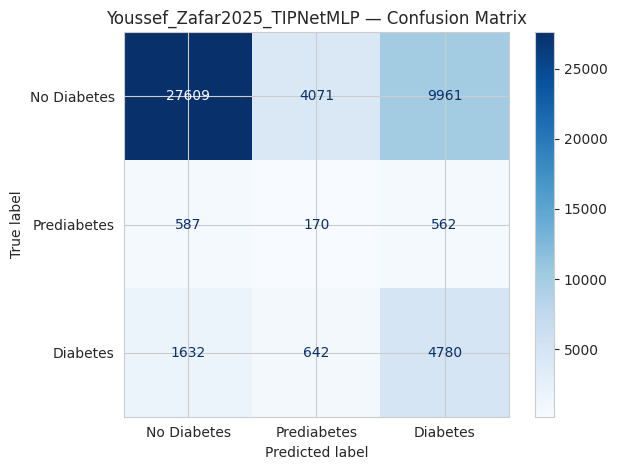

In [ ]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

# 0) Get predictions and probabilities first
y_pred_proba = keras_model.predict(X_test_sc)         # shape (n_samples, n_classes)
y_pred = np.argmax(y_pred_proba, axis=1)

# 1) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.tight_layout()
plt.show()

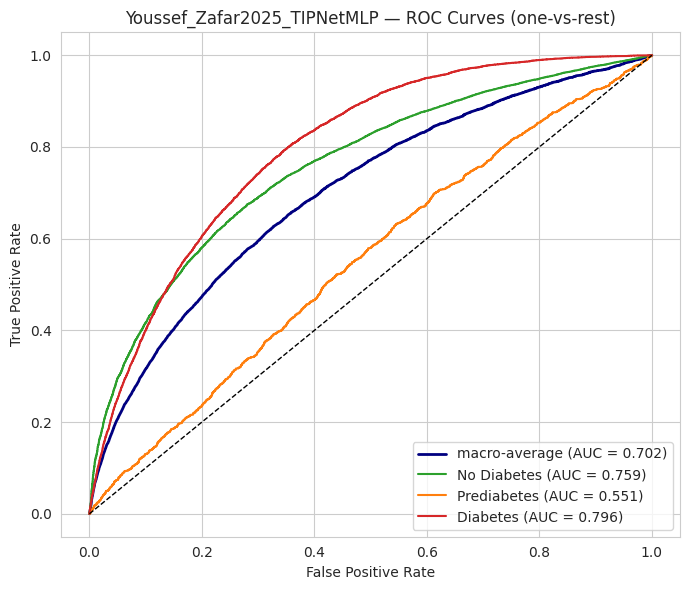

In [ ]:

y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
n_classes = y_test_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
plt.plot(all_fpr, mean_tpr,
         label=f"macro-average (AUC = {roc_auc['macro']:.3f})",
         color="navy", linewidth=2)

colors = ["tab:green", "tab:orange", "tab:red"]
for i, c in zip(range(n_classes), colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=c, lw=1.5,
             label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{MODEL_NAME} — ROC Curves (one-vs-rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

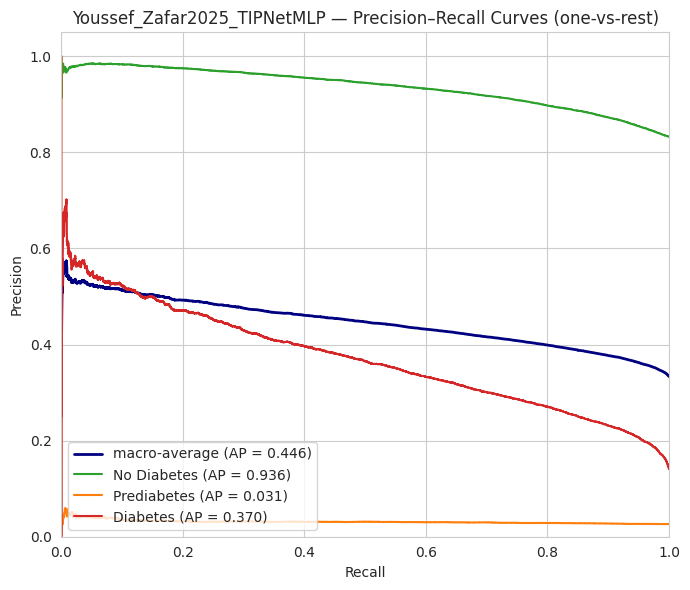

In [ ]:
precision = {}
recall = {}
ap = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i], y_pred_proba[:, i]
    )
    ap[i] = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])

# Macro-average PR
all_recalls = np.unique(np.concatenate([recall[i] for i in range(n_classes)]))
mean_precision = np.zeros_like(all_recalls)
for i in range(n_classes):
    r = recall[i]
    p = precision[i]
    order = np.argsort(r)
    r_sorted = r[order]
    p_sorted = p[order]
    mean_precision += np.interp(all_recalls, r_sorted, p_sorted)
mean_precision /= n_classes
ap["macro"] = auc(all_recalls, mean_precision)

plt.figure(figsize=(7, 6))
plt.plot(all_recalls, mean_precision,
         label=f"macro-average (AP = {ap['macro']:.3f})",
         color="navy", linewidth=2)

for i, c in zip(range(n_classes), colors[:n_classes]):
    plt.plot(recall[i], precision[i], lw=1.5, color=c,
             label=f"{CLASS_NAMES[i]} (AP = {ap[i]:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{MODEL_NAME} — Precision–Recall Curves (one-vs-rest)")
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

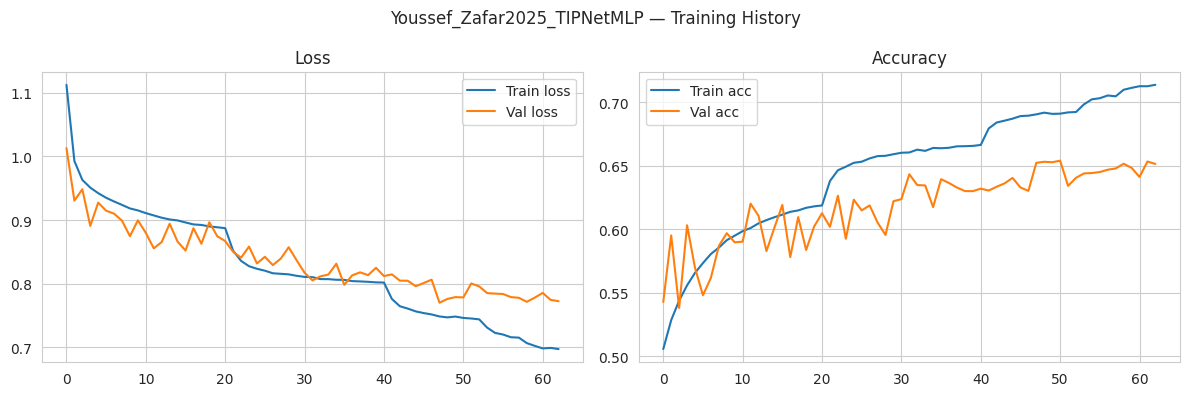

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.suptitle(f'{MODEL_NAME} — Training History')
plt.tight_layout(); plt.show()

##  Evaluation on Test Set

Accuracy           : 0.6510
Precision (weighted): 0.8156
Recall    (weighted): 0.6510
F1 weighted         : 0.7050
F1 macro            : 0.4183

              precision    recall  f1-score   support

 No Diabetes       0.93      0.66      0.77     41641
 Prediabetes       0.03      0.13      0.05      1319
    Diabetes       0.31      0.68      0.43      7054

    accuracy                           0.65     50014
   macro avg       0.42      0.49      0.42     50014
weighted avg       0.82      0.65      0.71     50014



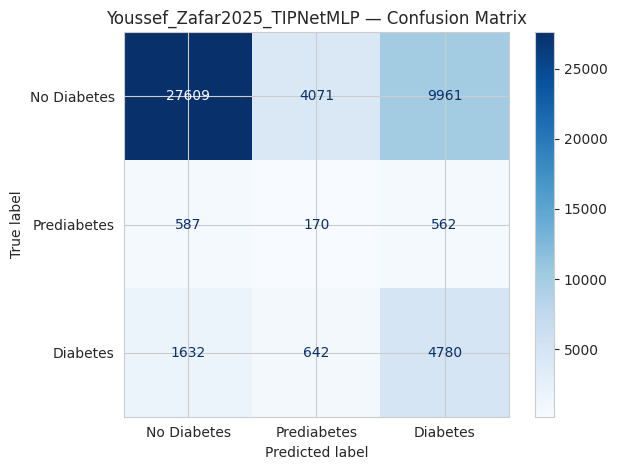

In [ ]:
y_pred_proba = keras_model.predict(X_test_sc, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test,  y_pred, average='weighted', zero_division=0)
f1w  = f1_score(y_test,     y_pred, average='weighted', zero_division=0)
f1m  = f1_score(y_test,     y_pred, average='macro',    zero_division=0)

print(f'Accuracy           : {acc:.4f}')
print(f'Precision (weighted): {prec:.4f}')
print(f'Recall    (weighted): {rec:.4f}')
print(f'F1 weighted         : {f1w:.4f}')
print(f'F1 macro            : {f1m:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap='Blues')
plt.title(f'{MODEL_NAME} — Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Sklearn-Compatible Wrapper (required for XAI tools)

In [ ]:
from sklearn.utils.multiclass import unique_labels

class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, keras_model):
        self.keras_model = keras_model

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        self.is_fitted_ = True
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_", "n_features_in_", "is_fitted_"])
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return self.keras_model.predict(X, verbose=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

wrapped = KerasWrapper(keras_model)
wrapped.fit(X_train_sc, y_train.values)
print('Wrapper ready. Test accuracy:', wrapped.score(X_test_sc, y_test.values))

Wrapper ready. Test accuracy: 0.6509977206382213


## XAI 1 — Permutation Feature Importance

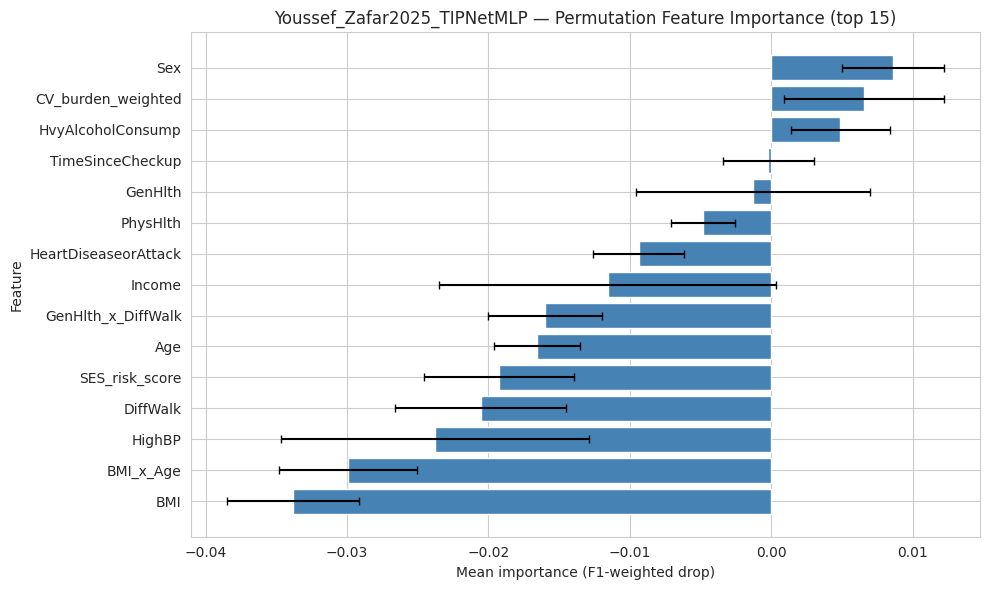

             feature  importance_mean  importance_std
                 Sex         0.008617        0.003607
  CV_burden_weighted         0.006545        0.005659
   HvyAlcoholConsump         0.004880        0.003480
    TimeSinceCheckup        -0.000202        0.003231
             GenHlth        -0.001295        0.008289
            PhysHlth        -0.004831        0.002250
HeartDiseaseorAttack        -0.009385        0.003227
              Income        -0.011563        0.011914
  GenHlth_x_DiffWalk        -0.015980        0.004021
                 Age        -0.016572        0.003042
      SES_risk_score        -0.019281        0.005296
            DiffWalk        -0.020540        0.006042
              HighBP        -0.023756        0.010883
           BMI_x_Age        -0.029930        0.004847
                 BMI        -0.033816        0.004653


In [ ]:
pfi_X, pfi_y = sk_resample(
    X_test_sc, y_test.values,
    n_samples=min(1000, len(y_test)),
    replace=False, random_state=RANDOM_STATE
)

pfi_result = permutation_importance(
    wrapped, pfi_X, pfi_y,
    n_repeats=5, random_state=RANDOM_STATE, scoring='f1_weighted'
)

pfi_df = pd.DataFrame({
    'feature':          feature_cols,
    'importance_mean':  pfi_result.importances_mean,
    'importance_std':   pfi_result.importances_std,
}).sort_values('importance_mean', ascending=False)

top_pfi = pfi_df.head(15).sort_values('importance_mean', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_pfi['feature'], top_pfi['importance_mean'],
         xerr=top_pfi['importance_std'], color='steelblue', ecolor='black', capsize=3)
plt.title(f'{MODEL_NAME} — Permutation Feature Importance (top 15)')
plt.xlabel('Mean importance (F1-weighted drop)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('/content/pfi_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_pfi.sort_values('importance_mean', ascending=False).to_string(index=False))

## XAI 2 — Partial Dependence Plots (PDP) & Individual Conditional Expectation (ICE)

,Feature,Importance
7,Sex,0.001294
13,HvyAlcoholConsump,-0.000129
18,TimeSinceCheckup,-0.000352
0,GenHlth,-0.003387
4,CV_burden_weighted,-0.004183
17,PhysHlth,-0.005450
12,HeartDiseaseorAttack,-0.011305
2,GenHlth_x_DiffWalk,-0.011638
6,DiffWalk,-0.015586
10,Income,-0.018890


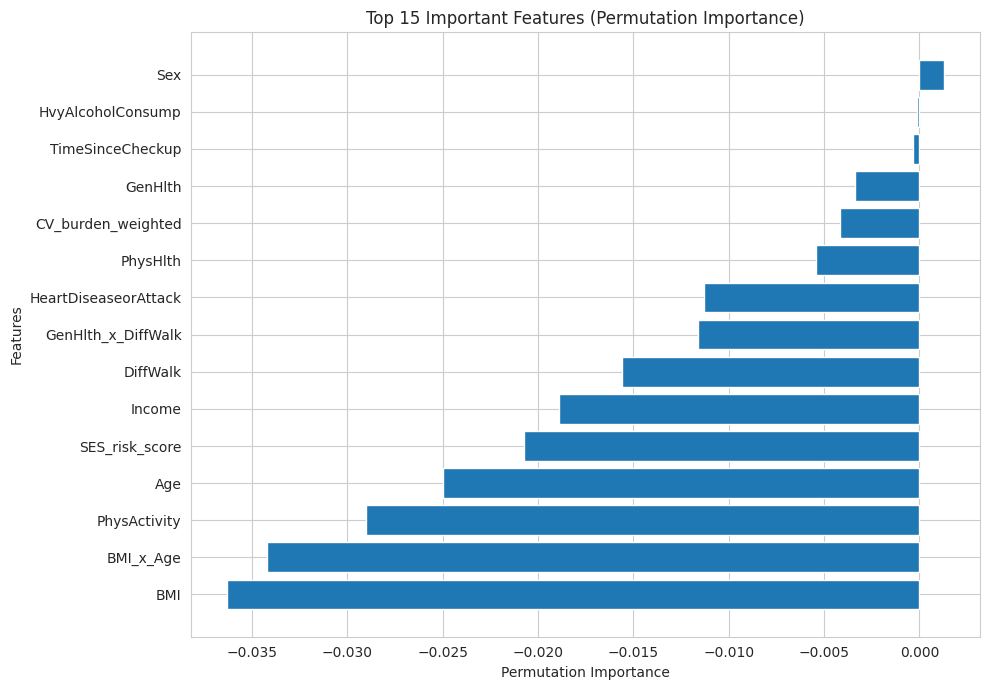

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


class KerasWrapper:
    def __init__(self, model):
        self.model = model
        self._estimator_type = "classifier"

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        probs = self.model.predict(X, verbose=0)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

wrapped_model = KerasWrapper(keras_model)
wrapped_model.fit(X_train_sc, y_train)


perm_importance = permutation_importance(
    estimator=wrapped_model,
    X=X_test_sc,
    y=y_test,
    scoring='f1_weighted',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_importance.importances_mean
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

display(importance_df.head(15))


plt.figure(figsize=(10, 7))

plt.barh(
    importance_df['Feature'][:15][::-1],
    importance_df['Importance'][:15][::-1]
)

plt.xlabel('Permutation Importance')
plt.ylabel('Features')
plt.title('Top 15 Important Features (Permutation Importance)')

plt.tight_layout()
plt.show()

## XAI 3 — SHAP (KernelExplainer)

  0%|          | 0/80 [00:00<?, ?it/s]

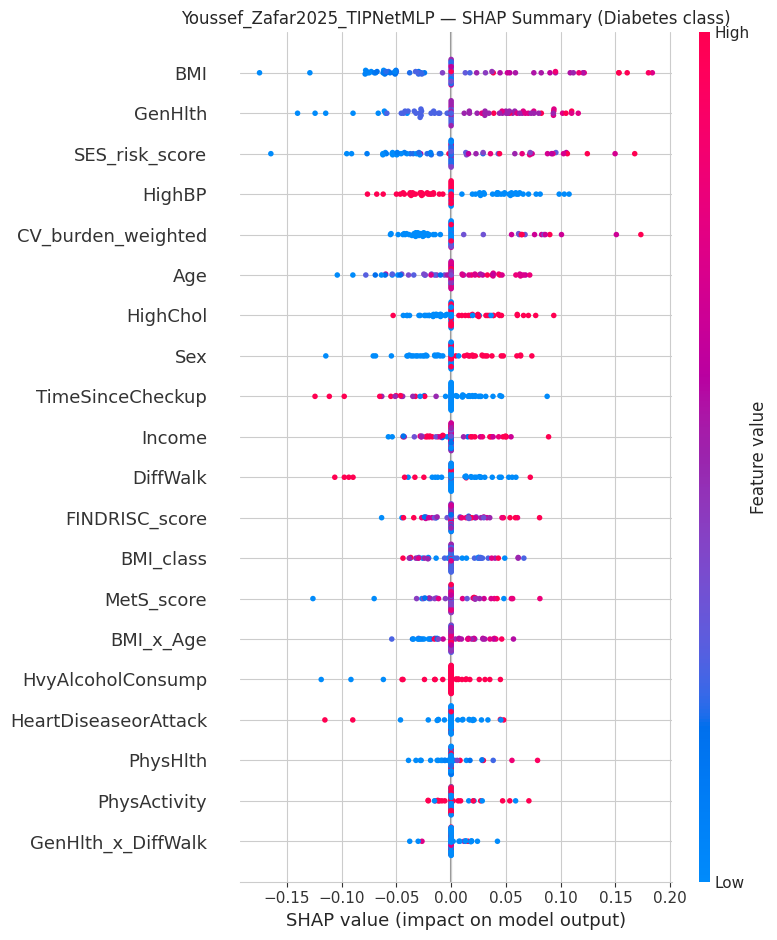

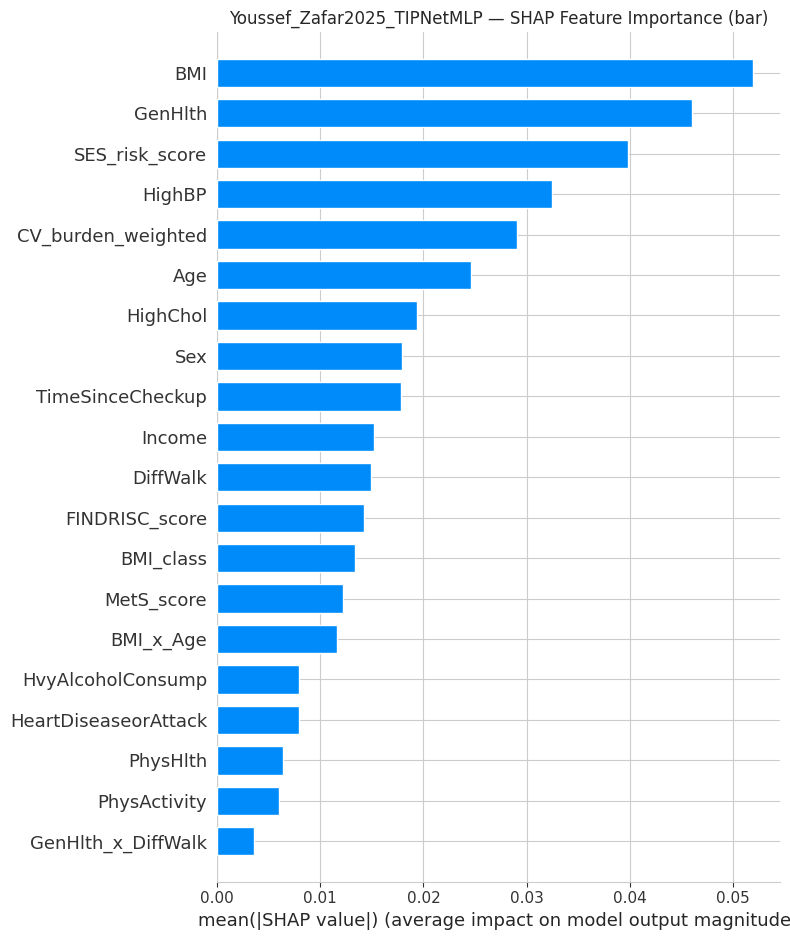

In [ ]:
shap_bg     = shap.sample(X_train_sc_df, 80, random_state=RANDOM_STATE)
shap_explXs = shap.sample(X_test_sc_df,  80, random_state=RANDOM_STATE)

def predict_class2_proba(data):
    return wrapped.predict_proba(np.asarray(data, dtype=np.float32))[:, 2]

explainer   = shap.KernelExplainer(predict_class2_proba, shap_bg)
shap_values = explainer.shap_values(shap_explXs, nsamples=100)

shap.summary_plot(shap_values, shap_explXs,
                  feature_names=feature_cols, show=False)
plt.title(f'{MODEL_NAME} — SHAP Summary (Diabetes class)')
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(shap_values, shap_explXs,
                  feature_names=feature_cols, plot_type='bar', show=False)
plt.title(f'{MODEL_NAME} — SHAP Feature Importance (bar)')
plt.tight_layout()
plt.savefig('/content/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## XAI 4 — LIME (Local Explanations)


--- LIME for sample 0 (No Diabetes) ---
True label: 0 | Predicted proba: [0.809 0.072 0.119]


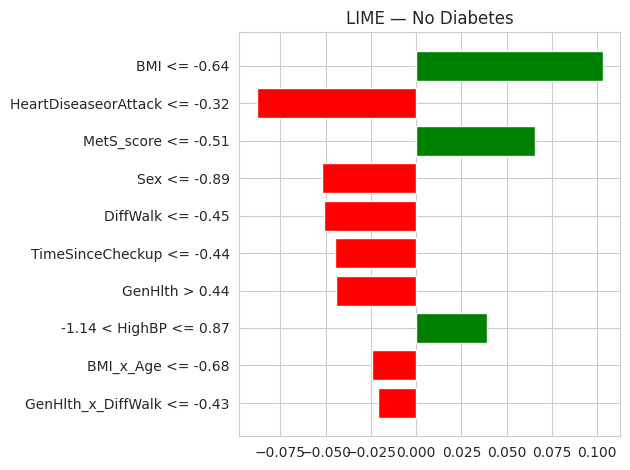


--- LIME for sample 10 (Prediabetes) ---
True label: 1 | Predicted proba: [0.886 0.043 0.071]


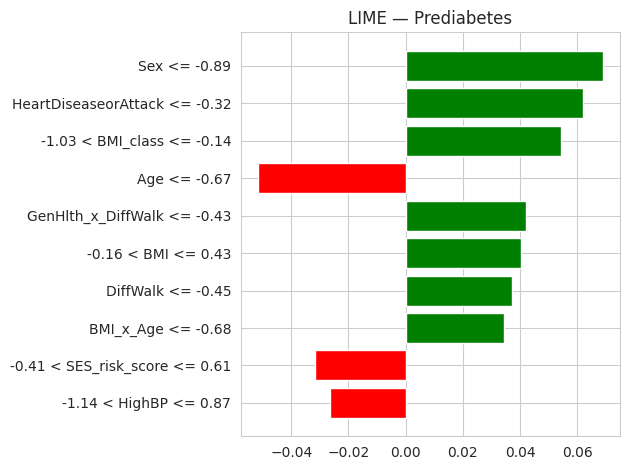


--- LIME for sample 18 (Diabetes) ---
True label: 2 | Predicted proba: [0.224 0.328 0.448]


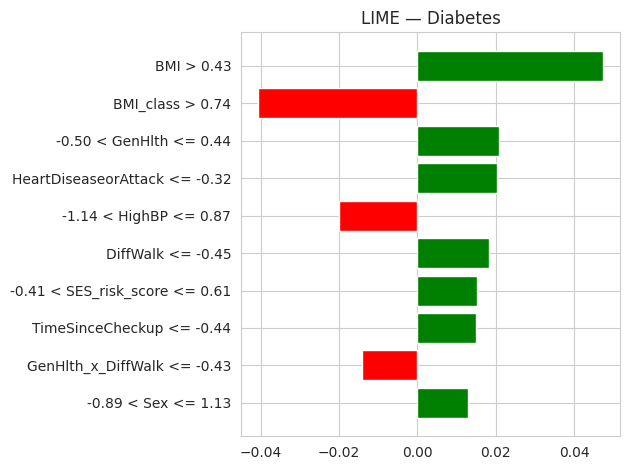

In [ ]:
lime_explainer = LimeTabularExplainer(
    X_train_sc,
    feature_names=feature_cols,
    class_names=CLASS_NAMES,
    discretize_continuous=True,
    mode='classification',
    random_state=RANDOM_STATE
)

for cls_idx, label in enumerate(CLASS_NAMES):

    match = np.where(y_test.values == cls_idx)[0]
    if len(match) == 0:
        print(f'No sample found for class {label}'); continue
    iloc = match[0]
    exp = lime_explainer.explain_instance(
        X_test_sc[iloc],
        wrapped.predict_proba,
        num_features=10, top_labels=n_classes
    )
    print(f'\n--- LIME for sample {iloc} ({label}) ---')
    print('True label:', y_test.iloc[iloc],
          '| Predicted proba:', wrapped.predict_proba(X_test_sc[[iloc]])[0].round(3))
    fig = exp.as_pyplot_figure(label=cls_idx)
    plt.title(f'LIME — {label}')
    plt.tight_layout()
    plt.savefig(f'/content/lime_{label.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## XAI 5 — Global Surrogate Decision Tree

Surrogate fidelity: 0.7754


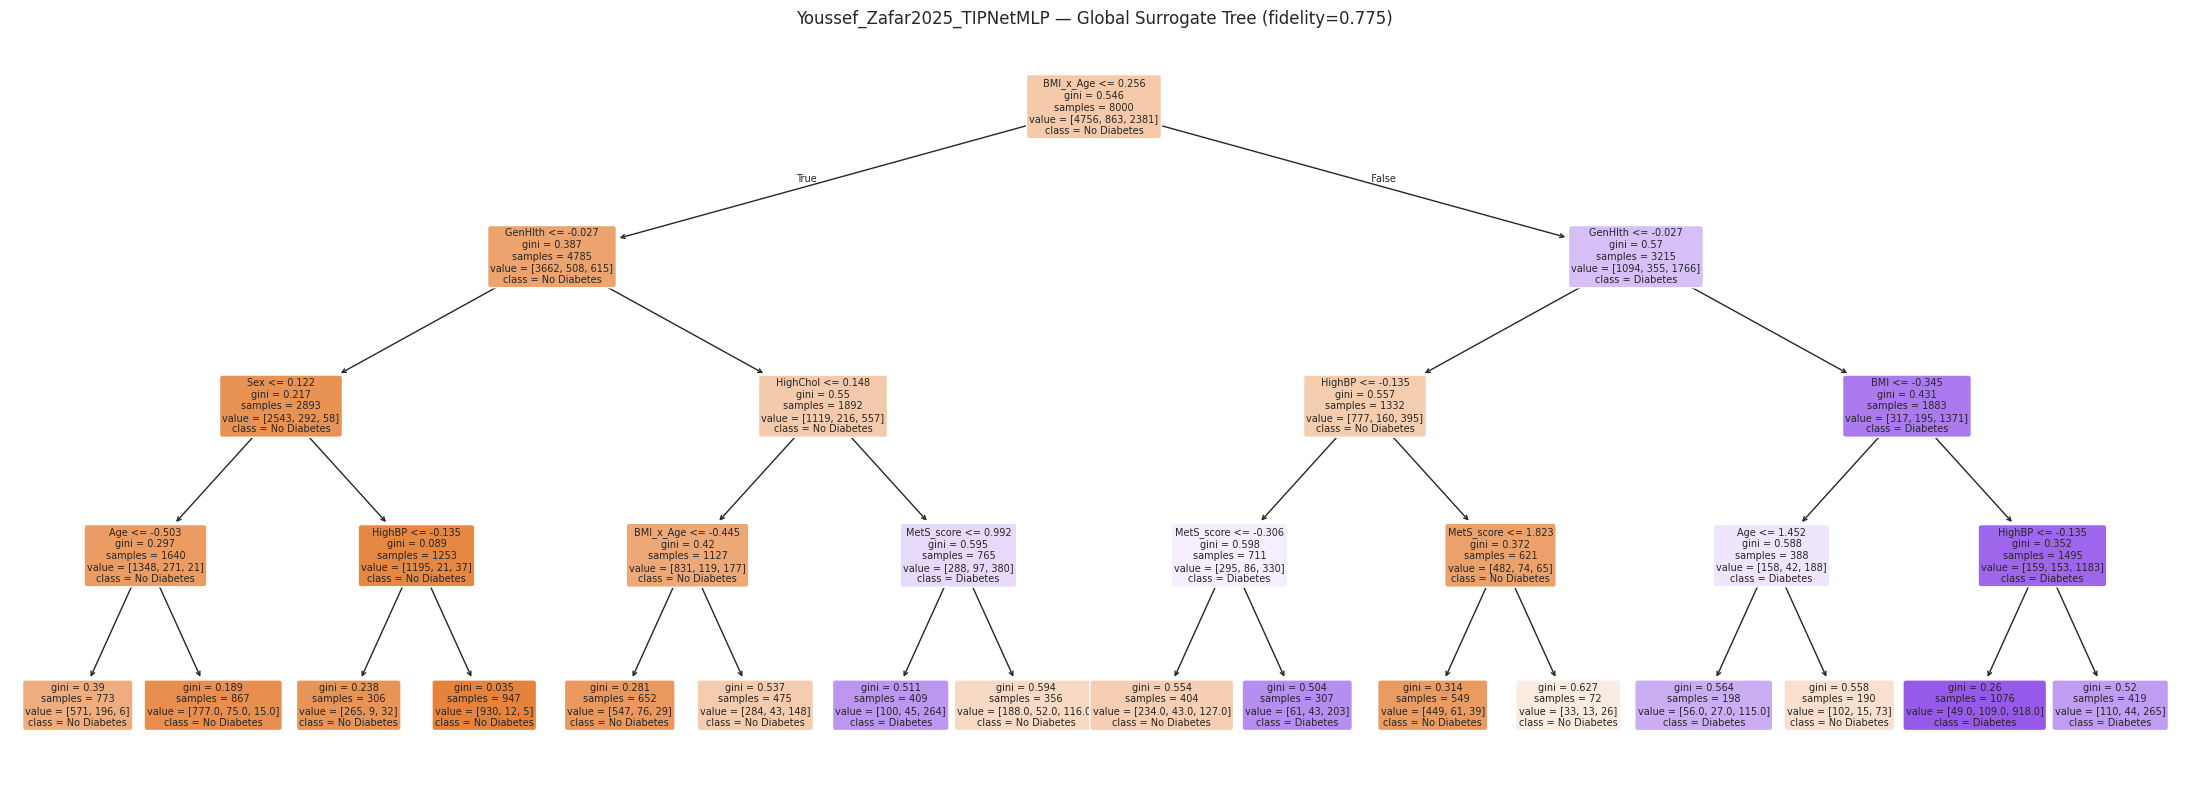

In [ ]:
X_sur_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(X_train_sc), size=min(8000, len(X_train_sc)), replace=False)
X_sur_np  = X_train_sc[X_sur_idx]
X_sur_df  = pd.DataFrame(X_sur_np, columns=feature_cols)

y_black   = wrapped.predict(X_sur_np)

surrogate = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
surrogate.fit(X_sur_df, y_black)

fidelity = accuracy_score(wrapped.predict(X_test_sc), surrogate.predict(X_test_sc_df))
print(f'Surrogate fidelity: {fidelity:.4f}')

plt.figure(figsize=(22, 8))
plot_tree(surrogate, feature_names=feature_cols,
          class_names=CLASS_NAMES, filled=True, rounded=True, fontsize=7)
plt.title(f'{MODEL_NAME} — Global Surrogate Tree (fidelity={fidelity:.3f})')
plt.tight_layout()
plt.savefig('/content/surrogate_tree.png', dpi=150, bbox_inches='tight')
plt.show()